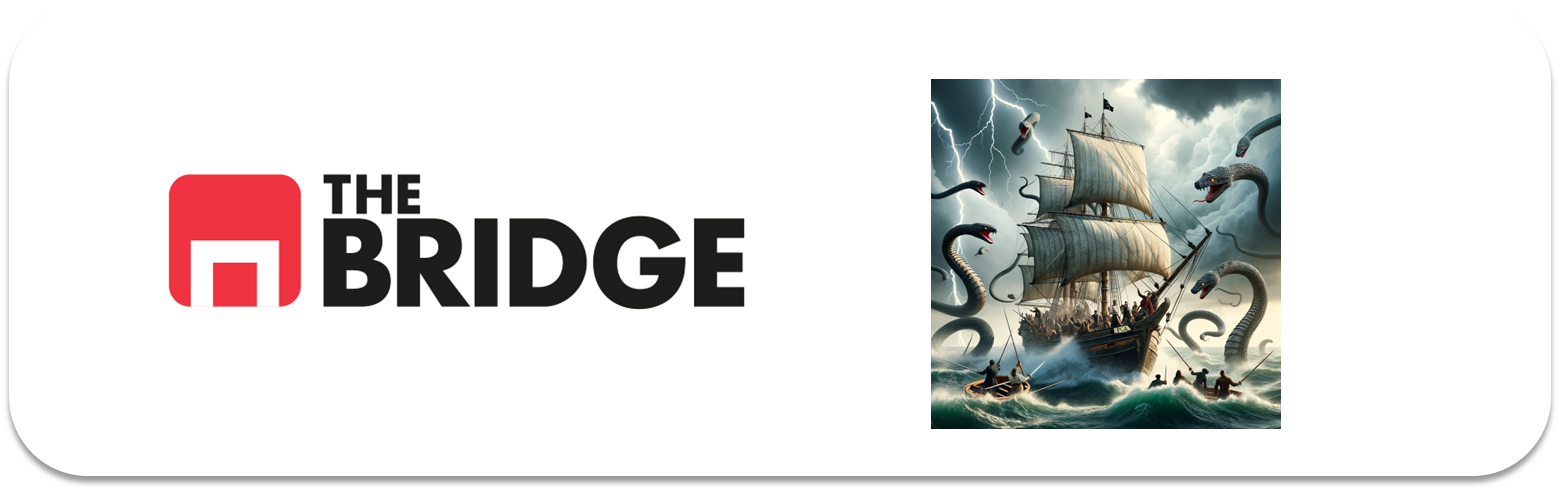

## PRACTICA OBLIGATORIA: **Seleccion Features**

* La práctica obligatoria de esta unidad consiste en hacer una comparativa de diferentes técnicas de selección de features sobre un dataset ya conocido. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Descripción General y Objetivo

El objetivo de la práctica es que juegues con las diferentes técncias de selección de features sobre un problema de clasificación. Para ello, tendrás que cargar el dataset de credit scoring que tienes en la carpeta "data" y que ya hemos trabajado anteriormente. A partir de ahí tendrás que probar diferentes técnicas de selección de features y compararlas todas entre sí y escoger finalmente el conjunto más sencillo con más potencia. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import bootcampviztools as bt
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from collections import Counter
from lightgbm import LGBMClassifier
from scipy.stats import mannwhitneyu
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, SelectFromModel, RFE, SequentialFeatureSelector
from sklearn.metrics import mutual_info_score, classification_report
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from xgboost import XGBClassifier

### Detalles e Instrucciones

El objetivo es que construyas un modelo final de clasificació sobre la variable "SeriousDlqin2yrs" del dataset que encontrarás en "data".  

Sigue los pasos del proceso de ML que hemos aprendido para problemas supervisados con el dataset que encontrarás en "data" pero con las siguiente salvedades:

1. Deshazte de las filas con nulos, para este ejercicio no nos importan. Convierte las features NumberOf... que creas conveniente a categóricas con 2 o 3 niveles a lo sumo.

2. A la hora de hacer el miniEda aplica los siguientes análisis y selección de features: 
    1. Análisis visual combinado con filtrado por valores de correlación y umbral de covarianza.
    2. Selección de features numéricas mediante SelectKBest y ANOVA, selecció de features categóricas mediante Mutual Information 
    3. Selección de las mejores features a través de un modelo intermedio (usando SelectFromModel)
    4. Selección de las mejores features empleando RFE.
    5. Selección de las mejores features empleando SFS.
    6. Selección de las mejores features mediante un sistema de hard-voting aplicado a lo obtenido en los pasos 1 a 5 anteriores.

    Para cada paso anterior (salvo el 1) se pide obtener una lista de features de "primera división" con un número de variables no superior a 6 (pueden ser menos).

3. Escoge tres modelos y a la hora compararlos para escoger el mejor, entrenalos con validación cruzada empleando las seis listas obtenidas anteriormente. Es decir tendrás 18 (6*3) medidas (emplea la métrica que creas más conveniente y si no se te ocurre ninguna el recall medio).  Escoge el mejor modelo y la mejor selección de features.

4. Optimiza los hiperparámetros del mejor modelo. Evalúalo contra test.


In [2]:
df = pd.read_csv("./data/credit_npo.csv")
df

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
12532,0,0.197116,59,0,0.290216,5140.0,6,0,1,0,0.0
12533,0,0.036726,62,0,0.884985,5833.0,12,0,1,0,0.0
12534,0,0.120313,49,0,0.577676,6333.0,7,0,2,0,2.0
12535,0,0.252566,63,0,0.037640,14000.0,9,0,0,0,1.0


In [3]:
df.info()
df.columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12537 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      12537 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  12537 non-null  float64
 2   age                                   12537 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  12537 non-null  int64  
 4   DebtRatio                             12537 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       12537 non-null  int64  
 7   NumberOfTimes90DaysLate               12537 non-null  int64  
 8   NumberRealEstateLoansOrLines          12537 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  12537 non-null  int64  
 10  NumberOfDependents                    12360 non-null  float64
dtypes: float64(4), 

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

In [4]:
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11816 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      11816 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  11816 non-null  float64
 2   age                                   11816 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  11816 non-null  int64  
 4   DebtRatio                             11816 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       11816 non-null  int64  
 7   NumberOfTimes90DaysLate               11816 non-null  int64  
 8   NumberRealEstateLoansOrLines          11816 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  11816 non-null  int64  
 10  NumberOfDependents                    11816 non-null  float64
dtypes: float64(4), int64

In [5]:
target = "SeriousDlqin2yrs"

In [6]:
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

## MINI - EDA

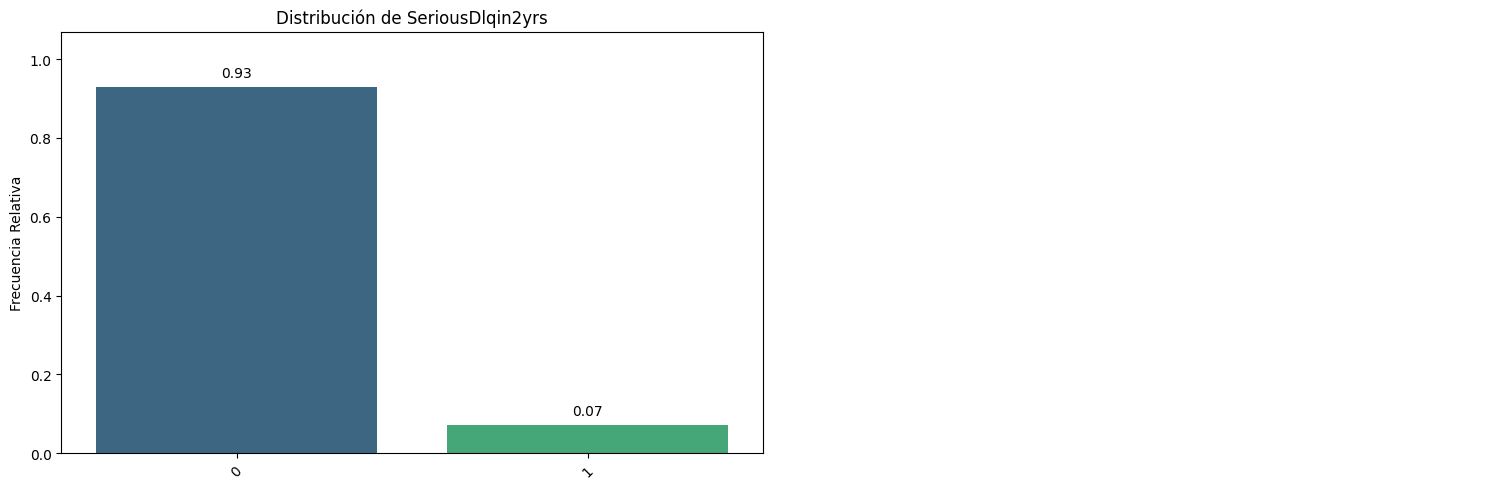

In [7]:
bt.pinta_distribucion_categoricas(df,[target], True, True) # sólo pintamos la distro del target
# está tan desbalanceada que se va a calcular el recall medio

In [8]:
train_set.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,9452.0,0.070144,0.255403,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,9452.0,0.335207,0.362233,0.0,0.034869,0.179211,0.587533,6.0
age,9452.0,51.491536,14.499298,21.0,41.000000,51.000000,62.000000,101.0
NumberOfTime30-59DaysPastDueNotWorse,9452.0,0.343314,2.930489,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,9452.0,0.486047,2.505031,0.0,0.146204,0.297564,0.477876,96.0
MonthlyIncome,9452.0,6868.428058,12580.543336,0.0,3466.000000,5441.000000,8300.000000,702500.0
NumberOfOpenCreditLinesAndLoans,9452.0,8.794647,5.139555,0.0,5.000000,8.000000,11.000000,49.0
NumberOfTimes90DaysLate,9452.0,0.180279,2.889984,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,9452.0,1.064325,1.148156,0.0,0.000000,1.000000,2.000000,19.0
NumberOfTime60-89DaysPastDueNotWorse,9452.0,0.152772,2.870119,0.0,0.000000,0.000000,0.000000,98.0


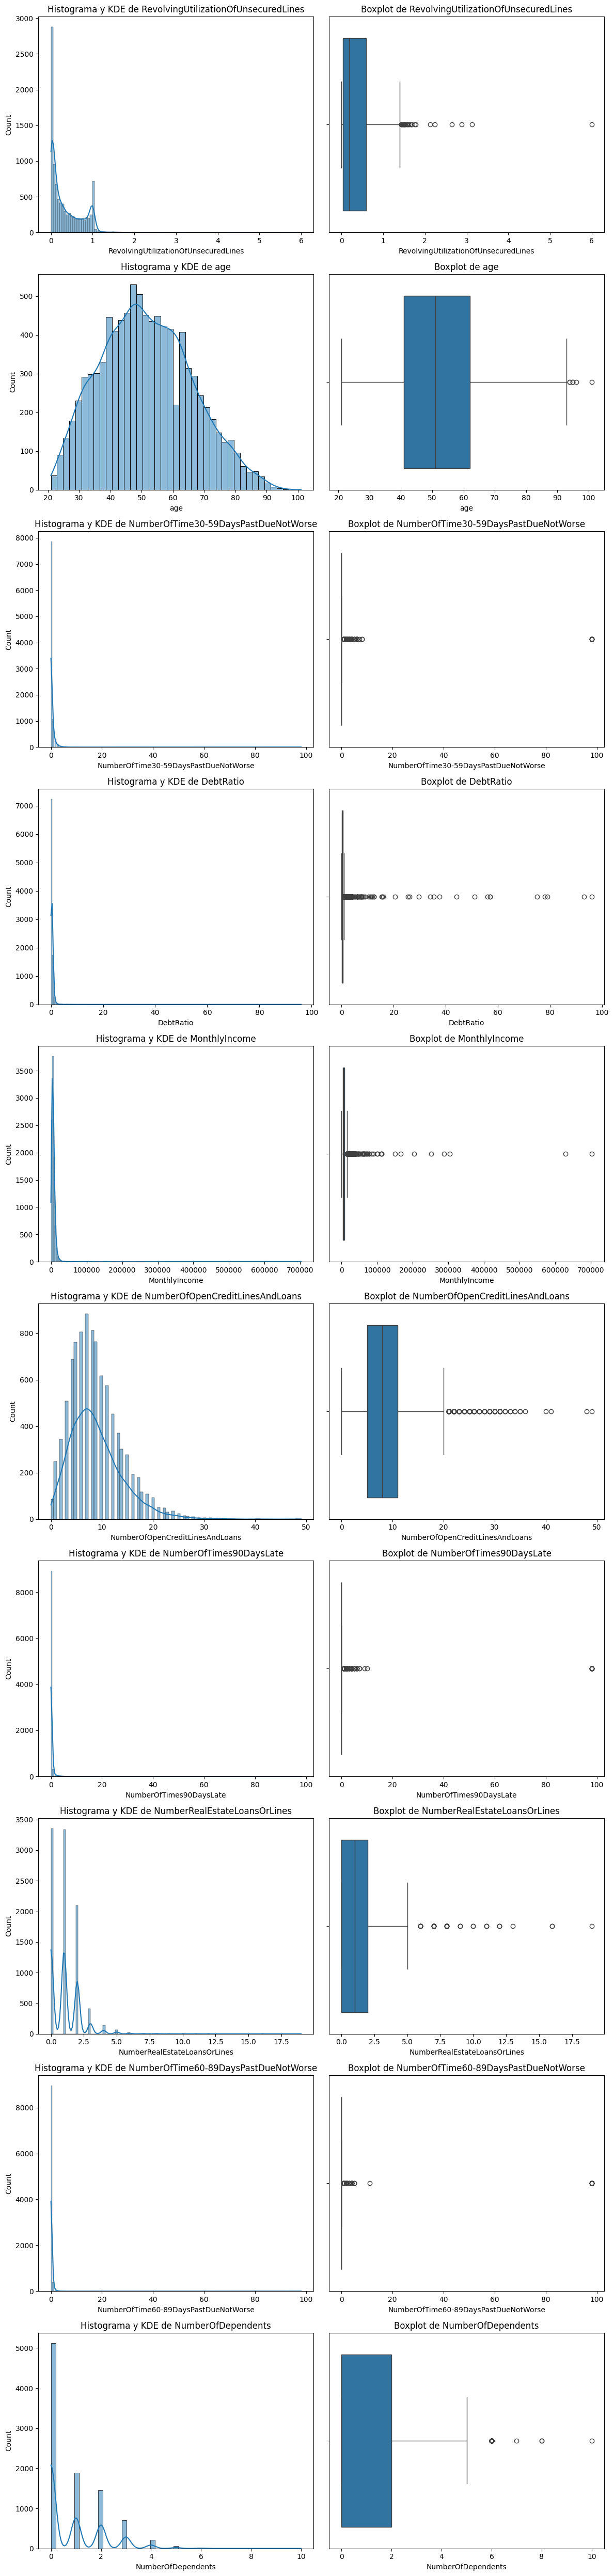

In [9]:
bt.plot_combined_graphs(train_set, [col for col in train_set.columns if col != target])

con estas gráficas podemos ver histograma y boxplot de cada columna para poder evaluar si una columna es discreta o continua. 
- RevolvingUtilizationOfUnsecuredLines: continua  
- age: discreta  
- NumberOfTime30-59DaysPastDueNotWorse: El valor 98 lo distorisiona, el resto de valores es cateorizable. se hará value_counts para decidir categorización  
- DebtRatio : La consideraremos ontinua por rango y valores   
- MonthlyIncome: continua   
- NumberOfOpenCreditLinesAndLoans: Numérica discreta pero por la cantidad de valores la trataremos como continua  
- NumberOfTimies90DaysLate: igual que la de 30-50Days. se categorizará  
- NumberRealEstateLoansOrLines: Los datos se concntran en 5 valores. se mirará su value counts y su bivariante con el target para determinar si se categorizará  
- NumberOfTime60-89DaysPastDueNotWorse: como las otras numberOfTimes sus datos se centran en 0 y tiene varios outliers y sesgada por el valor 98 se categorizará tras verificar value_counts  
- NubmerOfDependents: Numérica discreta. No tocar  

Columnas numéricas continuas

In [10]:
features_num = [
    'RevolvingUtilizationOfUnsecuredLines',
    'age',
    'DebtRatio',
    'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberOfDependents' ## ??
]

In [11]:
# porcentaje o distribución de los valores de la columna NumberOfDependents

display(train_set['NumberOfDependents'].value_counts(True)*100)
# vemos que la totalidad se concentra en los valores entre 0-6 que son los valores con los que nos vamos a quedar para quitarnos los outliers



NumberOfDependents
0.0     54.221329
1.0     19.942869
2.0     15.308929
3.0      7.490478
4.0      2.211172
5.0      0.581887
6.0      0.201016
8.0      0.021160
7.0      0.010580
10.0     0.010580
Name: proportion, dtype: float64

In [12]:
# tratamiento de las columnas numberoff
columnas_numberof = [col for col in df.columns if col.startswith('NumberOf')]

for col in columnas_numberof:
    distribucion_porcentaje = (df[col].value_counts(normalize=True, dropna = False).sort_index()) # normalize conteo en porcentaje (entre 0 y 1) (vs frecuencias absolutas)
    # dropna false (se incluyen los Nan como una categoría más)
    porcentaje_ceros = distribucion_porcentaje.get(0.0)
    print(f"\n{col} | valores_unicos = {df[col].nunique()} | porcentaje_ceros = {porcentaje_ceros:.2%}")
    print((distribucion_porcentaje.head(10) * 100).round(0))

## vemos la distribución de los datos de esas columnas que se concentran en los cinco - seis primeros valores


NumberOfTime30-59DaysPastDueNotWorse | valores_unicos = 10 | porcentaje_ceros = 83.09%
NumberOfTime30-59DaysPastDueNotWorse
0     83.0
1     11.0
2      3.0
3      1.0
4      1.0
5      0.0
6      0.0
7      0.0
8      0.0
98     0.0
Name: proportion, dtype: float64

NumberOfOpenCreditLinesAndLoans | valores_unicos = 43 | porcentaje_ceros = 0.95%
NumberOfOpenCreditLinesAndLoans
0    1.0
1    3.0
2    4.0
3    5.0
4    7.0
5    8.0
6    9.0
7    9.0
8    9.0
9    8.0
Name: proportion, dtype: float64

NumberOfTimes90DaysLate | valores_unicos = 13 | porcentaje_ceros = 94.41%
NumberOfTimes90DaysLate
0    94.0
1     3.0
2     1.0
3     0.0
4     0.0
5     0.0
6     0.0
7     0.0
8     0.0
9     0.0
Name: proportion, dtype: float64

NumberOfTime60-89DaysPastDueNotWorse | valores_unicos = 8 | porcentaje_ceros = 94.84%
NumberOfTime60-89DaysPastDueNotWorse
0     95.0
1      4.0
2      1.0
3      0.0
4      0.0
5      0.0
11     0.0
98     0.0
Name: proportion, dtype: float64

NumberOfDependent

In [13]:
# De esta columna también nos vamos a quedar con los valores en los que se centra casi la totalidad de los datos
display(train_set['NumberRealEstateLoansOrLines'].value_counts(True) * 100)
# así que de moment la incluimos en las featues numéricas
features_num.append('NumberRealEstateLoansOrLines')


NumberRealEstateLoansOrLines
0     35.505713
1     35.272958
2     22.164621
3      4.369446
4      1.449429
5      0.708845
6      0.201016
8      0.084638
7      0.084638
11     0.031739
12     0.031739
9      0.031739
10     0.021160
16     0.021160
13     0.010580
19     0.010580
Name: proportion, dtype: float64

TRATAMINETO DE LAS COLUMNAS NumberOf... eliminación de outliers

- NumberOfTime30-59DaysPastDueNotWorse: El valor 98 lo distorisiona, el resto de valores es cateorizable. se hará value_counts para decidir categorización  

-  NumberOfTimies90DaysLate: igual que la de 30-50Days. se categorizará  
- NumberRealEstateLoansOrLines: Los datos se concntran en 5 valores. se mirará su value counts y su bivariante con el target para determinar si se categorizará    
- NumberOfTime60-89DaysPastDueNotWorse: como las otras numberOfTimes sus datos se centran en 0 y tiene varios outliers y sesgada por el valor 98 se categorizará tras verificar value_counts 

59DaysPastDueNotWorse

In [14]:
col_30_59 = "NumberOfTime30-59DaysPastDueNotWorse"
train_set[train_set[target]==0][col_30_59].value_counts(True)

NumberOfTime30-59DaysPastDueNotWorse
0     0.855956
1     0.103083
2     0.026852
3     0.007851
4     0.003413
5     0.001138
6     0.001024
98    0.000341
8     0.000228
7     0.000114
Name: proportion, dtype: float64

In [15]:
labels = [0, 1, 2]

train_set["N30-59"] = pd.cut(train_set[col_30_59], bins=[-1, 0, 1, np.inf], labels=labels, right=True).astype(int)

In [16]:
# tenemos  que hacer la misma operación 
test_set["N30-59"] = pd.cut(test_set[col_30_59], bins=[-1, 0, 1, np.inf], labels=labels, right=True).astype(int)
train_set["N30-59"].value_counts(True)

N30-59
0    0.831147
1    0.113521
2    0.055332
Name: proportion, dtype: float64

NumberOfTime60-89DaysPastDueNotWorse. Nos quedamos con todas las columnas que están en 0 el resto es despreciable, así que lo agrupamos en uno, hacemos lo msmo cambiando la columna

In [17]:
train_set["N60-89"] = (train_set["NumberOfTime60-89DaysPastDueNotWorse"] > 0).astype(int)
test_set["N60-89"] = (test_set["NumberOfTime60-89DaysPastDueNotWorse"] > 0).astype(int)
# es una forma de binarizar porque lo que hace es crear una máscara booleana True si el valor es 1,2..etc false si es = 0, astype ocnvierte el true y false en 1 y 0 respectivamente
train_set["N60-89"].value_counts(True) 

N60-89
0    0.947207
1    0.052793
Name: proportion, dtype: float64

NumberOfTimies90DaysLate: igual que la de 30-50Days. se categorizará  

In [18]:
train_set["N90"] = (train_set["NumberOfTimes90DaysLate"] > 0).astype(int)
test_set["N90"] = (test_set["NumberOfTimes90DaysLate"] > 0).astype(int)
train_set["N90"].value_counts(True)

N90
0    0.94361
1    0.05639
Name: proportion, dtype: float64

In [19]:
features_cat = [
    "N30-59",
    "N60-89",
    "N90"
]

In [20]:
features_num

['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'DebtRatio',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfDependents',
 'NumberRealEstateLoansOrLines']

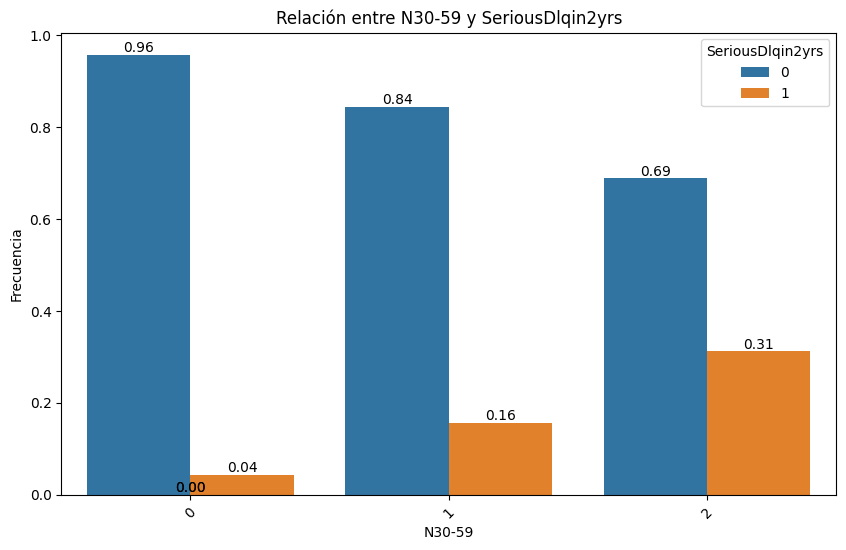

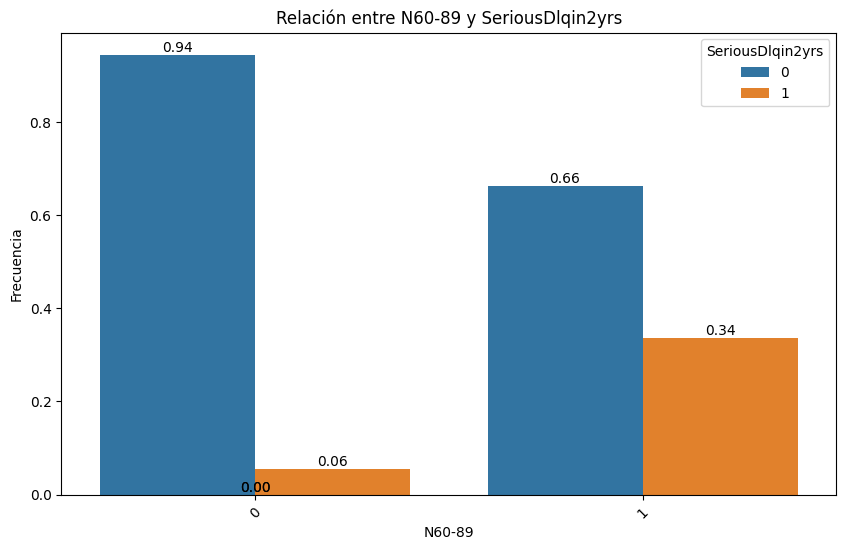

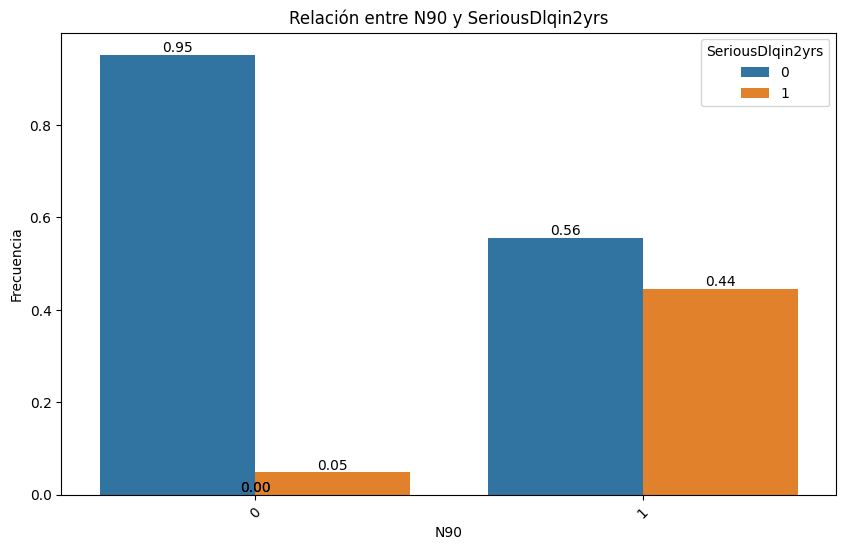

In [21]:
for col in features_cat:
    bt.plot_categorical_relationship_fin(train_set, col, target, True, True) # pintamos la relación entre las features categóricas y el target

In [22]:
features_visual = features_cat.copy()

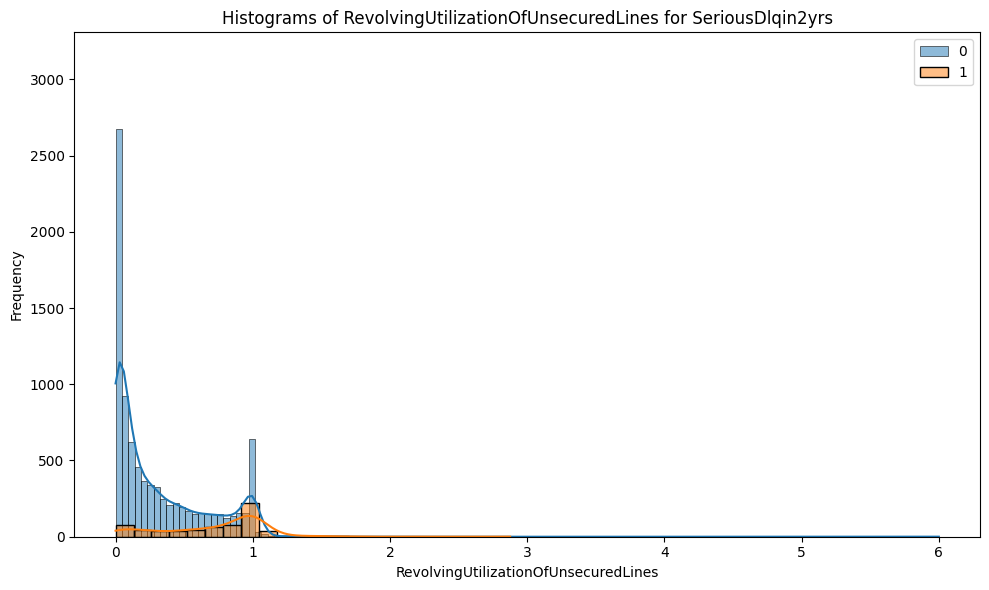

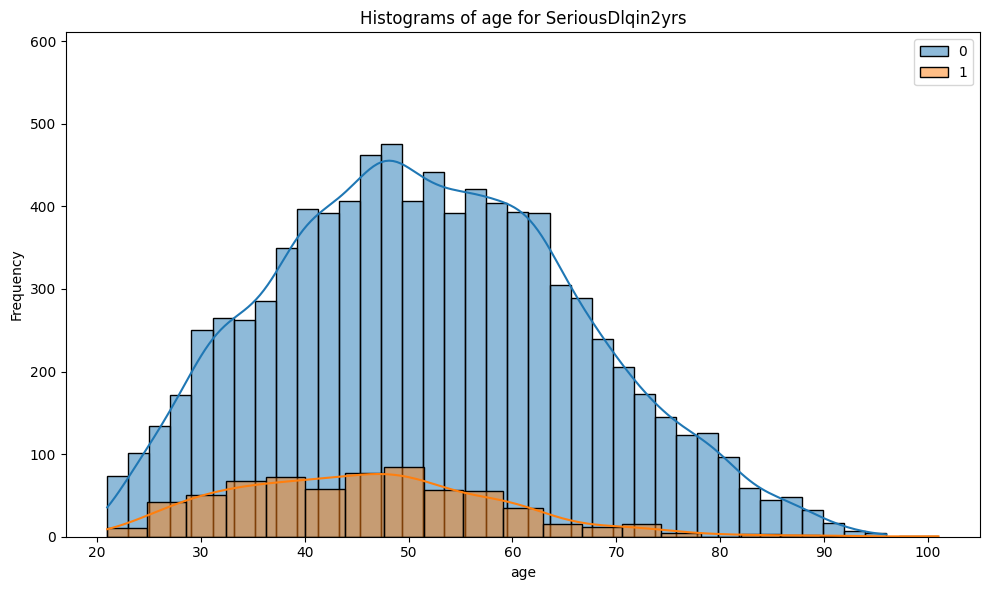

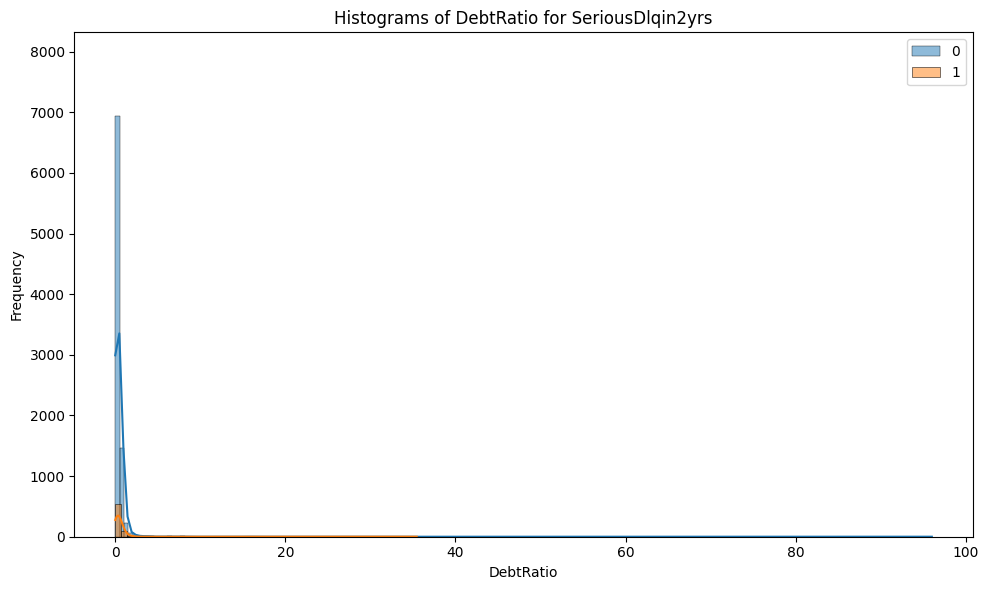

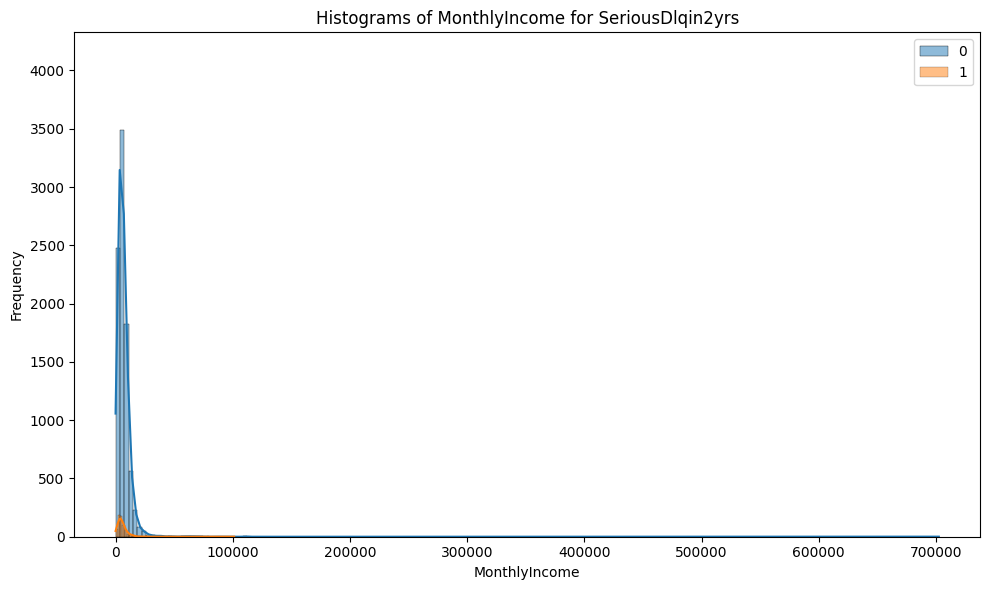

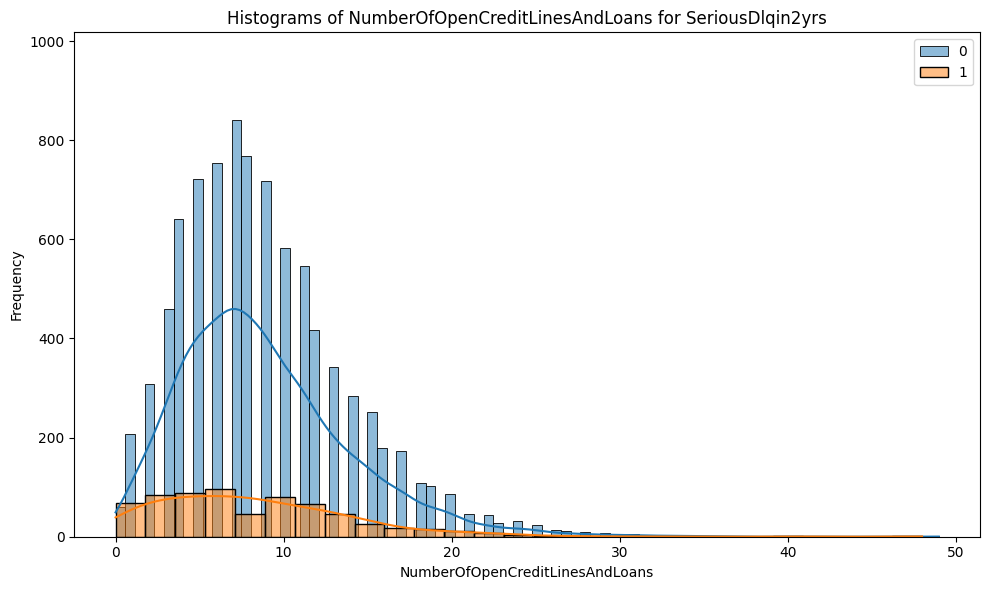

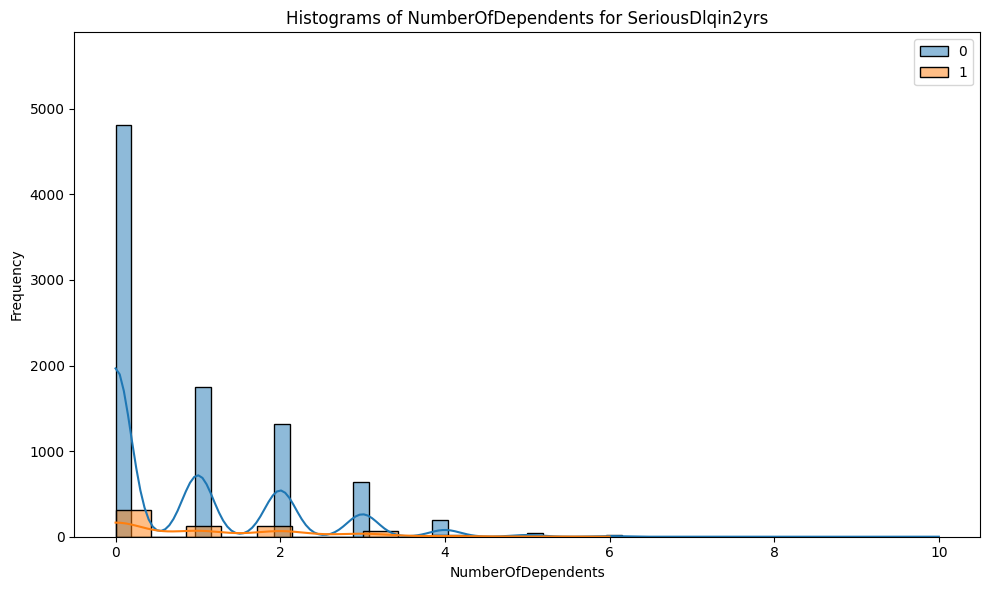

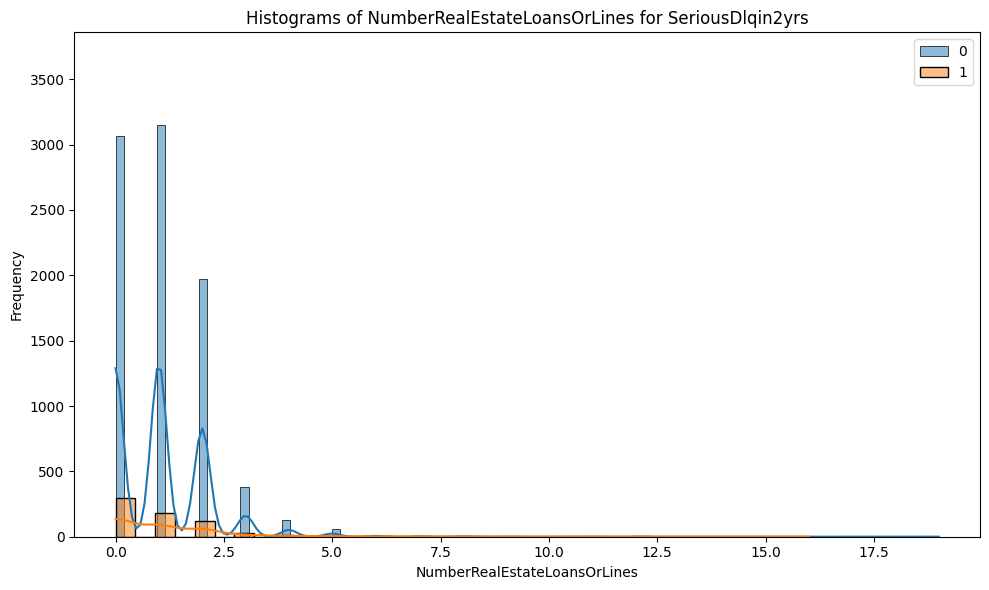

In [23]:
for col in features_num:
    bt.plot_grouped_histograms(train_set, cat_col=target, num_col=col, group_size = 2) #pintamos la relación entre las features numéricas y el target

hay dos features que no siguen la misma distribución como veremos: RevolvingUtilizationOfUnsecuredLines y NumberOfOpenCreditLinesAndLoans

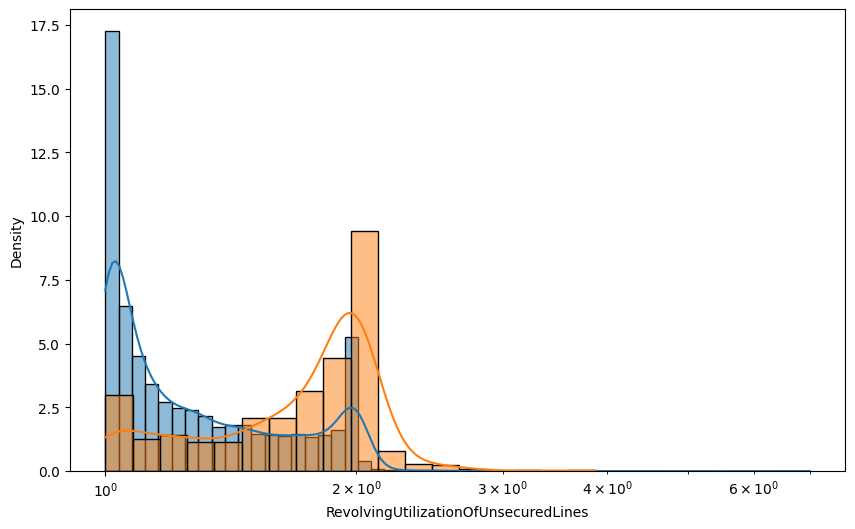

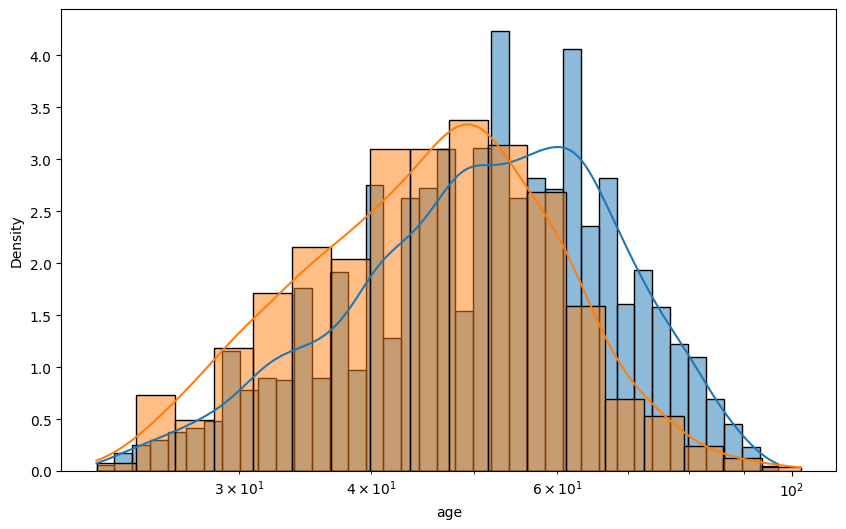

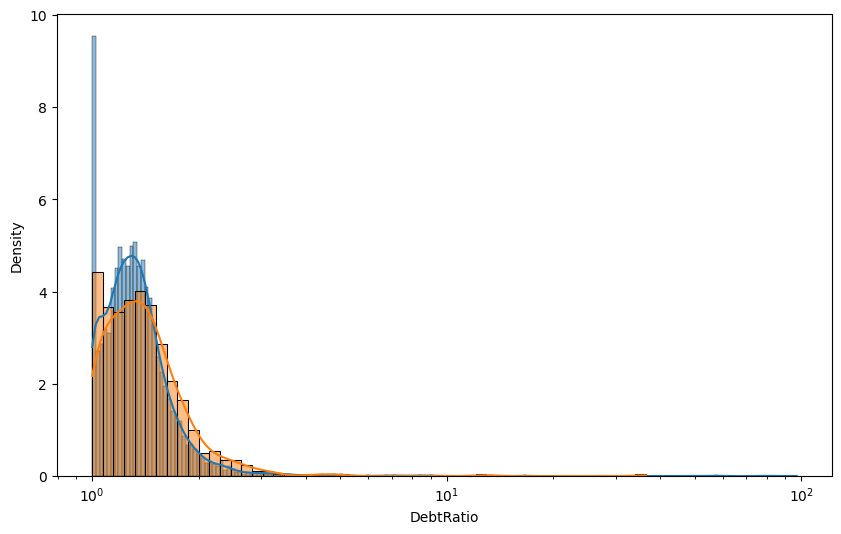

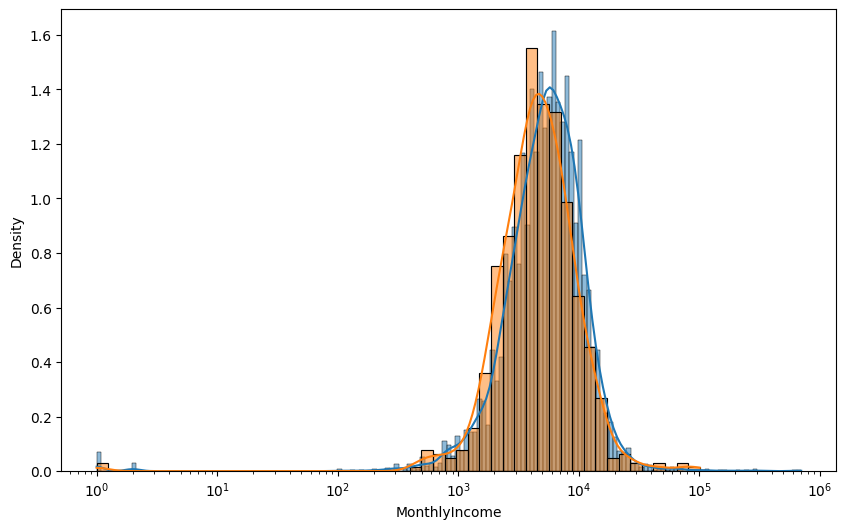

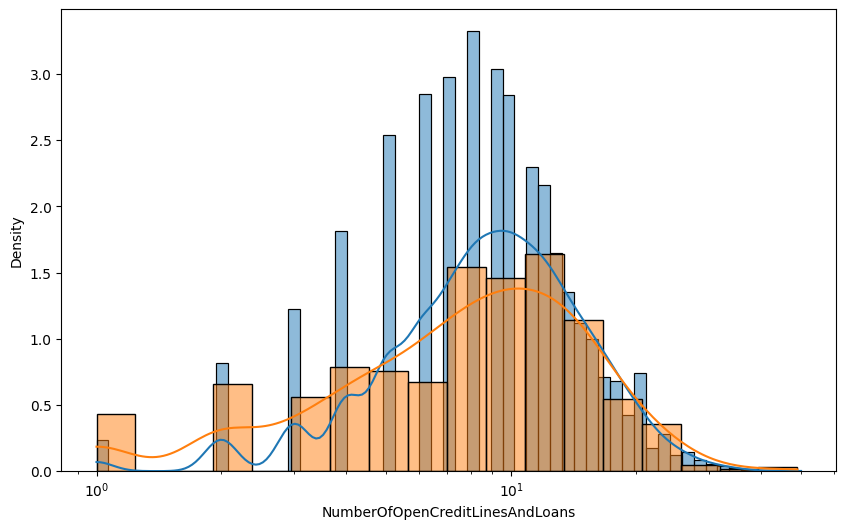

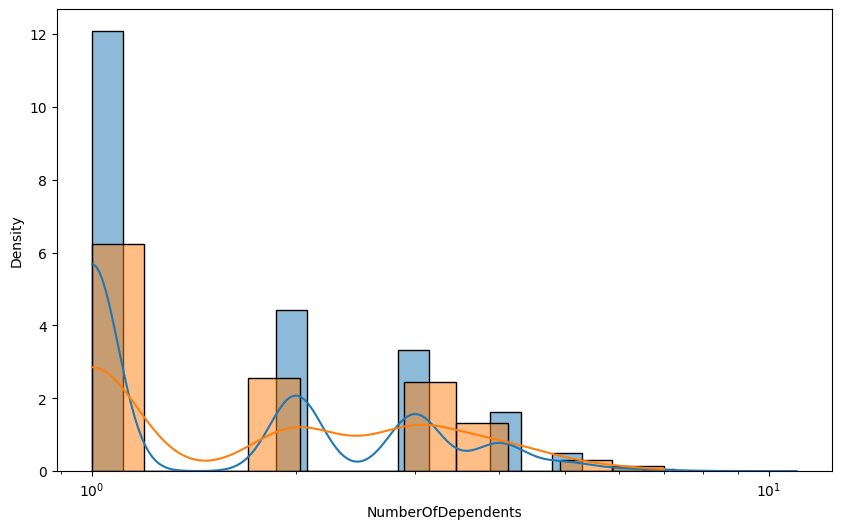

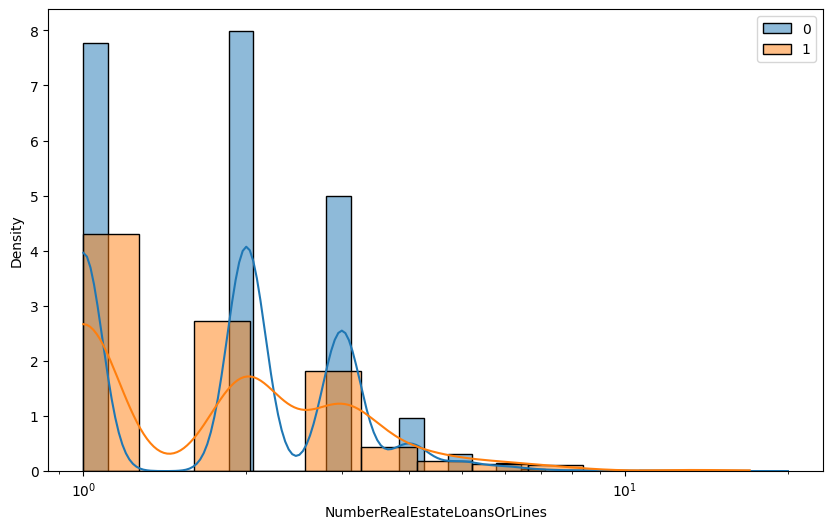

In [ ]:
#cambiamos la escala de la gráfica para ver mejor la distribución que difiere de los valores 1 y 0 para el target

for col in features_num:
    plt.figure(figsize=(10, 6))
    sns.histplot(train_set.loc[df[target] == 0] +1,
        x = col,
        kde = True,
        stat="density",
        log_scale=10, 
        label="0")
    sns.histplot(train_set.loc[df[target] == 1] +1,
        x = col,
        kde = True,
        stat="density",
        log_scale=10, 
        label="1")  
plt.legend()
plt.show()

In [25]:
features_visual.append("RevolvingUtilizationOfUnsecuredLines")

la edad a mayor de 70 años no se suelen aprobar créditos

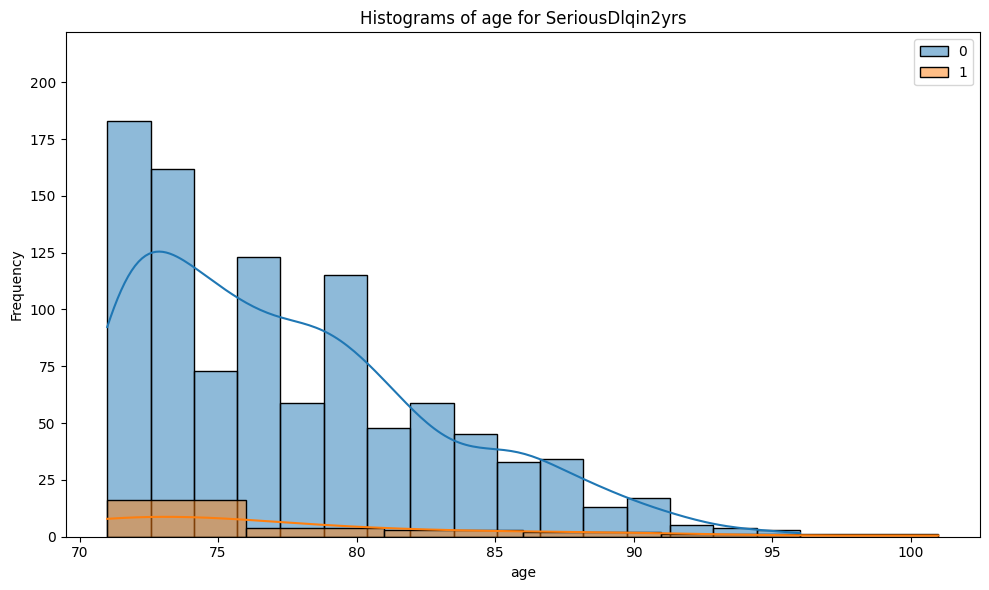

In [28]:
edad_cool = (train_set["age"] > 70) 

bt.plot_grouped_histograms(train_set[edad_cool], cat_col=target, num_col="age", group_size = 2) #pintamos la relación entre las features numéricas y el target

a más de 70 años hay bastante más impaagos

In [ ]:
features_visual.append("age")

monthlye income y dbtratio  
- DebtRatio : La consideraremos ontinua por rango y valores   
- MonthlyIncome: continua  

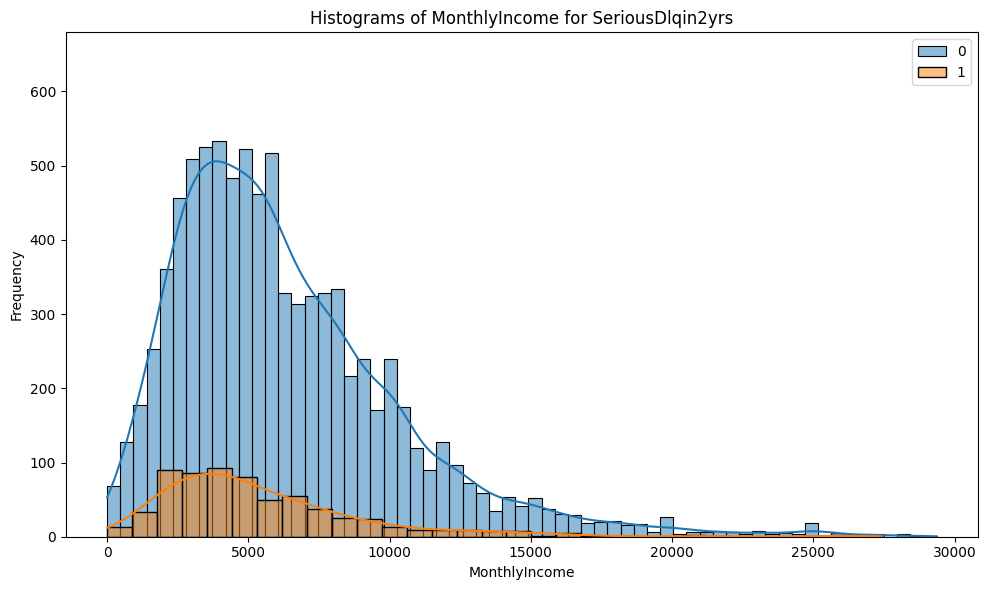

In [29]:
sin_monthlyincom_outliers = (train_set["MonthlyIncome"] < 30_000)
bt.plot_grouped_histograms(train_set[sin_monthlyincom_outliers], cat_col=target, num_col="MonthlyIncome", group_size = 2) #pintamos la relación entre las features numéricas y el target

hay más impagos a partir entre 3000 y 10000 confimamos con 

In [30]:
cat_col = target
num_col = 'MonthlyIncome'
# aplicamos pruba U de mann-whithney test estadístico no paramétrico que compara
# dos muestras independientes para determinar si sus poblaciones tienen distribuciones diferentes. 
# es la alternativa no paramétrica de la prueba dt de t student
# es decir cuando la distribución es muy asimétrica nos permite ver si las distribuciones son diferentes

grupo_a = train_set[train_set[cat_col] == 0][num_col]
grupo_b = train_set[train_set[cat_col] == 1][num_col]

u_stats, p_valor = mannwhitneyu(grupo_a, grupo_b)
print(f'U-statistic: {u_stats:.2f}, p-value: {p_valor:.4f}')

U-statistic: 3309844.00, p-value: 0.0000


el p valor debe ser menosr de 0.05

In [ ]:
features_visual.append("MonthlyIncome")

análisis dbratio

In [31]:
train_set["DebtRatio"].describe()

count    9452.000000
mean        0.486047
std         2.505031
min         0.000000
25%         0.146204
50%         0.297564
75%         0.477876
max        96.000000
Name: DebtRatio, dtype: float64

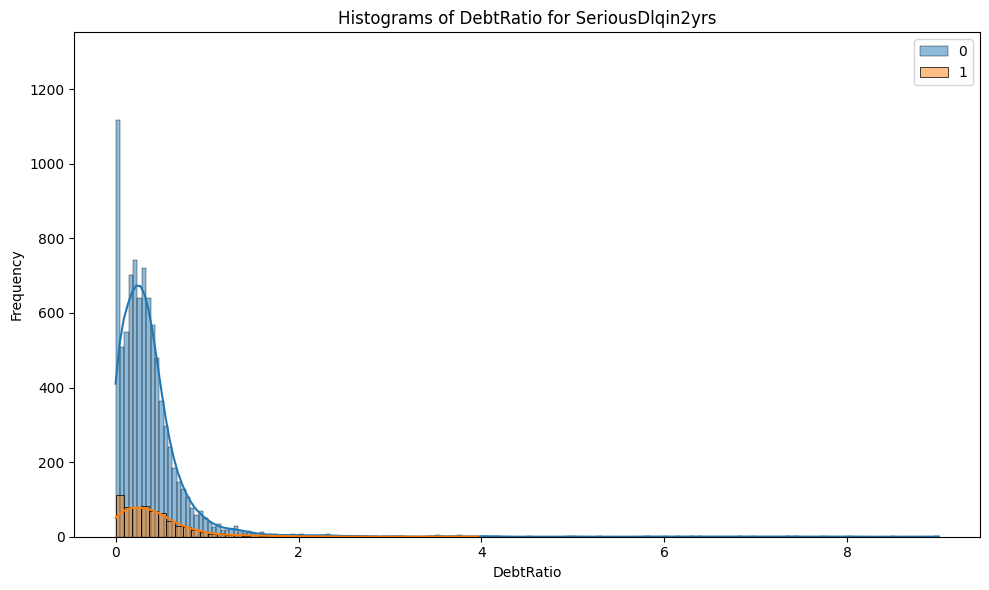

In [32]:
sin_debt_ratio_outliers = (train_set["DebtRatio"] < 10)
bt.plot_grouped_histograms(train_set[sin_debt_ratio_outliers], cat_col=target, num_col="DebtRatio", group_size = 2) #pintamos la relación entre las features numéricas y el target

In [ ]:
cat_col = target
num_col = 'DebtRatio'
# aplicamos pruba U de mann-whithney test estadístico no paramétrico que compara
# dos muestras independientes para determinar si sus poblaciones tienen distribuciones diferentes. 
# es la alternativa no paramétrica de la prueba dt de t student
# es decir cuando la distribución es muy asimétrica nos permite ver si las distribuciones son diferentes

grupo_a = train_set[train_set[cat_col] == 0][num_col]
grupo_b = train_set[train_set[cat_col] == 1][num_col]

u_stats, p_valor = mannwhitneyu(grupo_a, grupo_b)
print(f'U-statistic: {u_stats:.2f}, p-value: {p_valor}')

U-statistic: 2623985.50, p-value: 0.0000


tambien el valor es menosr de 0.05 así que la incluimos

In [34]:
features_visual.append("DebtRatio")
features_visual

['N30-59',
 'N60-89',
 'N90',
 'RevolvingUtilizationOfUnsecuredLines',
 'DebtRatio']

hacmeos análisis de umbral de varianza

In [35]:
for umbral_varianza in np.arange(0, 1, 0.1):
    print(f'para umbral_varianza={umbral_varianza}')
    var_selector = VarianceThreshold(threshold=umbral_varianza)
    var_selector.fit(train_set[features_visual])
    print('Lista seleccionada por el selector de Varianza', var_selector.get_feature_names_out())

para umbral_varianza=0.0
Lista seleccionada por el selector de Varianza ['N30-59' 'N60-89' 'N90' 'RevolvingUtilizationOfUnsecuredLines'
 'DebtRatio']
para umbral_varianza=0.1
Lista seleccionada por el selector de Varianza ['N30-59' 'RevolvingUtilizationOfUnsecuredLines' 'DebtRatio']
para umbral_varianza=0.2
Lista seleccionada por el selector de Varianza ['N30-59' 'DebtRatio']
para umbral_varianza=0.30000000000000004
Lista seleccionada por el selector de Varianza ['DebtRatio']
para umbral_varianza=0.4
Lista seleccionada por el selector de Varianza ['DebtRatio']
para umbral_varianza=0.5
Lista seleccionada por el selector de Varianza ['DebtRatio']
para umbral_varianza=0.6000000000000001
Lista seleccionada por el selector de Varianza ['DebtRatio']
para umbral_varianza=0.7000000000000001
Lista seleccionada por el selector de Varianza ['DebtRatio']
para umbral_varianza=0.8
Lista seleccionada por el selector de Varianza ['DebtRatio']
para umbral_varianza=0.9
Lista seleccionada por el selector

con pocas categorías o pococ elquilibradas el selector las descarta así que nos quedamos con todas

In [36]:
features_visual

['N30-59',
 'N60-89',
 'N90',
 'RevolvingUtilizationOfUnsecuredLines',
 'DebtRatio']

la edad la tenemos también en las numéricas

In [37]:
X_train = train_set[features_num]
y_train = train_set[target]

In [ ]:
f_classif(X_train, y_train)
# nos devuelve lla clasificación e importans de las variables 

(array([8.29602605e+02, 1.11110548e+02, 3.27949461e-02, 3.11838171e+00,
        9.97516759e+00, 1.42688783e+01, 2.65741768e-02]),
 array([6.12914400e-175, 7.78315943e-026, 8.56297874e-001, 7.74459141e-002,
        1.59165160e-003, 1.59435900e-004, 8.70509418e-001]))

In [39]:
# hacemos el selector de numéricas
selector_num = SelectKBest(score_func=f_classif, k=4)
X_data_kbest = selector_num.fit_transform(X_train, y_train)

X_train_kbest = pd.DataFrame(X_data_kbest, columns=selector_num.get_feature_names_out())
X_train_kbest

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfOpenCreditLinesAndLoans,NumberOfDependents
0,0.391240,68.0,13.0,0.0
1,0.906540,59.0,7.0,1.0
2,0.933223,52.0,3.0,3.0
3,0.857859,50.0,9.0,0.0
4,0.000000,61.0,5.0,1.0
...,...,...,...,...
9447,0.397822,53.0,14.0,0.0
9448,0.015171,76.0,4.0,0.0
9449,0.988201,62.0,4.0,0.0
9450,0.122072,41.0,9.0,1.0


nos reduce las features a 4

In [40]:
#metemos las columans en una lista pra filtrar 
features_filter = list(selector_num.get_feature_names_out())
features_filter

['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfDependents']

In [41]:
features_cat

['N30-59', 'N60-89', 'N90']

In [ ]:
from sklearn.feature_selection import mutual_info_classif

X_train = train_set[features_cat]
y_train = train_set[target]

selector_cat = SelectKBest(score_func=mutual_info_classif, k=3)  # ordenará por importancia pero nos quedamos con las tres
x_data_kbest_cat = selector_cat.fit_transform(X_train, y_train)

X_train_kbest_cat = pd.DataFrame(x_data_kbest_cat, columns=selector_cat.get_feature_names_out())
X_train_kbest_cat



,N30-59,N60-89,N90
0,0,0,0
1,0,0,0
2,1,0,0
3,0,0,0
4,0,0,0
...,...,...,...
9447,0,0,0
9448,0,0,0
9449,0,0,0
9450,0,0,0


In [45]:
features_filter +=features_cat

mutual_info_classif(X_train, y_train, random_state=42)
# hacemos el infor classifier cuantifica la información que aporta una variable para reducir la incertidumbre
# 0 significa que son totalmente independientes o no aportan información útil
# de vuelve una matriz de valores float tantos valores como columnas evaluadas e
# en función de la teoría de la información en Nats unidades naturales de la ifnormación 
# bvbasado en logaritmos para medir la entropia

features_filter

['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfDependents',
 'N30-59',
 'N60-89',
 'N90',
 'N30-59',
 'N60-89',
 'N90']

verificación con un modelo

In [46]:
features = features_num + features_cat

rf_selector = RandomForestClassifier(random_state=42, class_weight='balanced')  # class_weight='balanced' para manejar el desbalanceo de clases

selector_modelo = SelectFromModel(estimator=rf_selector, threshold='median')  # selecciona las características cuya importancia es mayor que la mediana
selector_modelo.fit(train_set[features], train_set[target])

features_model = list(selector_modelo.get_feature_names_out())

features_model

['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'DebtRatio',
 'MonthlyIncome',
 'N30-59']

In [ ]:
features_visual # corregir alguna se me ha ido me faltan age, RevolvingUtilizationOfUnsecuredLines, DebtRatio, MonthlyIncome, 

['N30-59',
 'N60-89',
 'N90',
 'RevolvingUtilizationOfUnsecuredLines',
 'DebtRatio']

In [49]:
rf_check = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_check.fit(train_set[features_visual], train_set[target])

df_importance = pd.DataFrame({'feature': features, 'importance': rf_check.feature_importances_})
df_importance

ValueError: All arrays must be of the same length

In [ ]:
df

### EXTRA

Aplica la PCA como método de selección, escoge un número de componentes en función de la varianza explicada y crea un dataset con el que entrenar el mismo tipo de modelo ganador de la parte general. Entrenalo y evalúalo contra test, comenta el resultado.